In [1]:
import pickle
import os
from pathlib import Path
from collections import defaultdict

# Define paths
base_path = Path('C:/Users/ihagv/Desktop/masters_project/project_code/cluster/phase_1_2_data/phase1')
distnet_metadata_path = base_path / 'distnet' / 'metadata'
tabpfn_metadata_path = base_path / 'tabpfn' / 'metadata'

def nested_dict():
    """Helper function to create nested defaultdicts"""
    return defaultdict(nested_dict)

# Initialize dictionaries
distnet_dict = nested_dict()
tabpfn_dict = nested_dict()

# Process distnet files
print("Processing distnet metadata files...")
for pkl_file in distnet_metadata_path.glob('*.pkl'):
    # Parse filename: distnet_scenario_fold_seed_context_...
    parts = pkl_file.stem.split('_')
    
    # Skip the first part (model name)
    # Extract scenario (can be multi-part like clasp_factoring, spear_qcp, etc.)
    # Find where the fold number is (should be a digit)
    
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):  # Skip 'distnet'
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    # Context size is after the None, None parts (positions fold_idx+4)
    context_size = parts[fold_idx + 4]
    
    # Load the pickle file
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    # Extract nllh from the metrics
    nllh = data['metrics']['nllh']
    
    # Store in nested dictionary
    distnet_dict[scenario][fold][context_size][seed_context] = nllh
    
print(f"Loaded {len(list(distnet_metadata_path.glob('*.pkl')))} distnet files")

# Process tabpfn files
print("Processing tabpfn metadata files...")
for pkl_file in tabpfn_metadata_path.glob('*.pkl'):
    # Parse filename: tabpfn_scenario_fold_seed_context_...
    parts = pkl_file.stem.split('_')
    
    # Skip the first part (model name)
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):  # Skip 'tabpfn'
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    # Context size is after the None, None parts
    context_size = parts[fold_idx + 4]
    
    # Load the pickle file
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    # Extract nllh from the metrics
    nllh = data['metrics']['nllh']
    
    # Store in nested dictionary
    tabpfn_dict[scenario][fold][context_size][seed_context] = nllh

print(f"Loaded {len(list(tabpfn_metadata_path.glob('*.pkl')))} tabpfn files")

# Convert defaultdicts to regular dicts for cleaner output
def convert_to_dict(d):
    if isinstance(d, defaultdict):
        d = {k: convert_to_dict(v) for k, v in d.items()}
    return d

distnet_dict = convert_to_dict(distnet_dict)
tabpfn_dict = convert_to_dict(tabpfn_dict)

# Test access
print("\n=== Testing dictionary access ===")
print("Available scenarios in distnet:", list(distnet_dict.keys()))
print("Available scenarios in tabpfn:", list(tabpfn_dict.keys()))

# Example access
if 'clasp_factoring' in distnet_dict:
    scenario = 'clasp_factoring'
    if '0' in distnet_dict[scenario]:
        fold = '0'
        if '128' in distnet_dict[scenario][fold]:
            context_size = '128'
            if '100' in distnet_dict[scenario][fold][context_size]:
                seed = '100'
                nllh_value = distnet_dict[scenario][fold][context_size][seed]
                print(f"\nExample: distnet['{scenario}']['{fold}']['{context_size}']['{seed}'] = {nllh_value}")

if 'clasp_factoring' in tabpfn_dict:
    scenario = 'clasp_factoring'
    if '0' in tabpfn_dict[scenario]:
        fold = '0'
        if '128' in tabpfn_dict[scenario][fold]:
            context_size = '128'
            if '100' in tabpfn_dict[scenario][fold][context_size]:
                seed = '100'
                nllh_value = tabpfn_dict[scenario][fold][context_size][seed]
                print(f"Example: tabpfn['{scenario}']['{fold}']['{context_size}']['{seed}'] = {nllh_value}")

print("\n=== Dictionaries created successfully! ===")
print(f"distnet_dict has {len(distnet_dict)} scenarios")
print(f"tabpfn_dict has {len(tabpfn_dict)} scenarios")

Processing distnet metadata files...
Loaded 2730 distnet files
Processing tabpfn metadata files...
Loaded 2730 tabpfn files

=== Testing dictionary access ===
Available scenarios in distnet: ['clasp_factoring', 'lpg-zeno', 'saps-CVVAR', 'spear_qcp', 'spear_swgcp', 'yalsat_qcp', 'yalsat_swgcp']
Available scenarios in tabpfn: ['clasp_factoring', 'lpg-zeno', 'saps-CVVAR', 'spear_qcp', 'spear_swgcp', 'yalsat_qcp', 'yalsat_swgcp']

Example: distnet['clasp_factoring']['0']['128']['100'] = 2.6543854950786487
Example: tabpfn['clasp_factoring']['0']['128']['100'] = -0.21020490527153016

=== Dictionaries created successfully! ===
distnet_dict has 7 scenarios
tabpfn_dict has 7 scenarios


In [2]:
# Define expected configurations
SCENARIOS = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno",
]

CONTEXT_SIZES = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
CONTEXT_SEEDS = [100, 200, 300]
FOLDS = range(10)

# Convert to strings for comparison (since dict keys are strings)
CONTEXT_SIZES_STR = [str(cs) for cs in CONTEXT_SIZES]
CONTEXT_SEEDS_STR = [str(cs) for cs in CONTEXT_SEEDS]
FOLDS_STR = [str(f) for f in FOLDS]

# Total expected configurations per model
total_expected = len(SCENARIOS) * len(CONTEXT_SIZES) * len(CONTEXT_SEEDS) * len(FOLDS)
print(f"Expected total configurations per model: {total_expected}")
print(f"  = {len(SCENARIOS)} scenarios × {len(CONTEXT_SIZES)} context sizes × {len(CONTEXT_SEEDS)} seeds × {len(FOLDS)} folds")

# Check distnet missing configurations
print("\n" + "="*80)
print("CHECKING DISTNET CONFIGURATIONS")
print("="*80)

distnet_missing = []
distnet_found = 0

for scenario in SCENARIOS:
    for fold in FOLDS_STR:
        for context_size in CONTEXT_SIZES_STR:
            for seed in CONTEXT_SEEDS_STR:
                try:
                    _ = distnet_dict[scenario][fold][context_size][seed]
                    distnet_found += 1
                except (KeyError, TypeError):
                    distnet_missing.append((scenario, fold, context_size, seed))

print(f"\nDistNet: Found {distnet_found}/{total_expected} configurations")
print(f"Missing: {len(distnet_missing)} configurations")

if distnet_missing:
    print("\n--- Missing DistNet Configurations ---")
    # Group by scenario for better readability
    from collections import defaultdict
    missing_by_scenario = defaultdict(list)
    for scenario, fold, context_size, seed in distnet_missing:
        missing_by_scenario[scenario].append((fold, context_size, seed))
    
    for scenario in SCENARIOS:
        if scenario in missing_by_scenario:
            missing_count = len(missing_by_scenario[scenario])
            print(f"\n{scenario}: {missing_count} missing")
            if missing_count <= 20:  # Show details if not too many
                for fold, context_size, seed in missing_by_scenario[scenario]:
                    print(f"  - fold={fold}, context_size={context_size}, seed={seed}")
            else:
                # Show summary
                missing_folds = set(f for f, _, _ in missing_by_scenario[scenario])
                missing_contexts = set(c for _, c, _ in missing_by_scenario[scenario])
                missing_seeds = set(s for _, _, s in missing_by_scenario[scenario])
                print(f"    Missing folds: {sorted(missing_folds)}")
                print(f"    Missing context sizes: {sorted(missing_contexts, key=int)}")
                print(f"    Missing seeds: {sorted(missing_seeds)}")

# Check tabpfn missing configurations
print("\n" + "="*80)
print("CHECKING TABPFN CONFIGURATIONS")
print("="*80)

tabpfn_missing = []
tabpfn_found = 0

for scenario in SCENARIOS:
    for fold in FOLDS_STR:
        for context_size in CONTEXT_SIZES_STR:
            for seed in CONTEXT_SEEDS_STR:
                try:
                    _ = tabpfn_dict[scenario][fold][context_size][seed]
                    tabpfn_found += 1
                except (KeyError, TypeError):
                    tabpfn_missing.append((scenario, fold, context_size, seed))

print(f"\nTabPFN: Found {tabpfn_found}/{total_expected} configurations")
print(f"Missing: {len(tabpfn_missing)} configurations")

if tabpfn_missing:
    print("\n--- Missing TabPFN Configurations ---")
    # Group by scenario for better readability
    missing_by_scenario = defaultdict(list)
    for scenario, fold, context_size, seed in tabpfn_missing:
        missing_by_scenario[scenario].append((fold, context_size, seed))
    
    for scenario in SCENARIOS:
        if scenario in missing_by_scenario:
            missing_count = len(missing_by_scenario[scenario])
            print(f"\n{scenario}: {missing_count} missing")
            if missing_count <= 20:  # Show details if not too many
                for fold, context_size, seed in missing_by_scenario[scenario]:
                    print(f"  - fold={fold}, context_size={context_size}, seed={seed}")
            else:
                # Show summary
                missing_folds = set(f for f, _, _ in missing_by_scenario[scenario])
                missing_contexts = set(c for _, c, _ in missing_by_scenario[scenario])
                missing_seeds = set(s for _, _, s in missing_by_scenario[scenario])
                print(f"    Missing folds: {sorted(missing_folds)}")
                print(f"    Missing context sizes: {sorted(missing_contexts, key=int)}")
                print(f"    Missing seeds: {sorted(missing_seeds)}")

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"DistNet:  {distnet_found}/{total_expected} ({100*distnet_found/total_expected:.1f}% complete)")
print(f"TabPFN:   {tabpfn_found}/{total_expected} ({100*tabpfn_found/total_expected:.1f}% complete)")

# Print missing configurations in requested format
print("\n" + "="*80)
print("MISSING CONFIGURATIONS LIST")
print("="*80)

if distnet_missing:
    print("\n--- DistNet Missing (format: SCENARIO FOLD CONTEXT_SEED CONTEXT_SIZE) ---")
    for scenario, fold, context_size, seed in distnet_missing:
        print(f"{scenario} {fold} {seed} {context_size}")

if tabpfn_missing:
    print("\n--- TabPFN Missing (format: SCENARIO FOLD CONTEXT_SEED CONTEXT_SIZE) ---")
    for scenario, fold, context_size, seed in tabpfn_missing:
        print(f"{scenario} {fold} {seed} {context_size}")

Expected total configurations per model: 2730
  = 7 scenarios × 13 context sizes × 3 seeds × 10 folds

CHECKING DISTNET CONFIGURATIONS

DistNet: Found 2730/2730 configurations
Missing: 0 configurations

CHECKING TABPFN CONFIGURATIONS

TabPFN: Found 2730/2730 configurations
Missing: 0 configurations

SUMMARY
DistNet:  2730/2730 (100.0% complete)
TabPFN:   2730/2730 (100.0% complete)

MISSING CONFIGURATIONS LIST


Processing distnet phase1 metadata files...
Loaded 2730 distnet phase1 files
Processing tabpfn phase1 metadata files...
Loaded 2730 tabpfn phase1 files

=== Dictionaries created successfully! ===


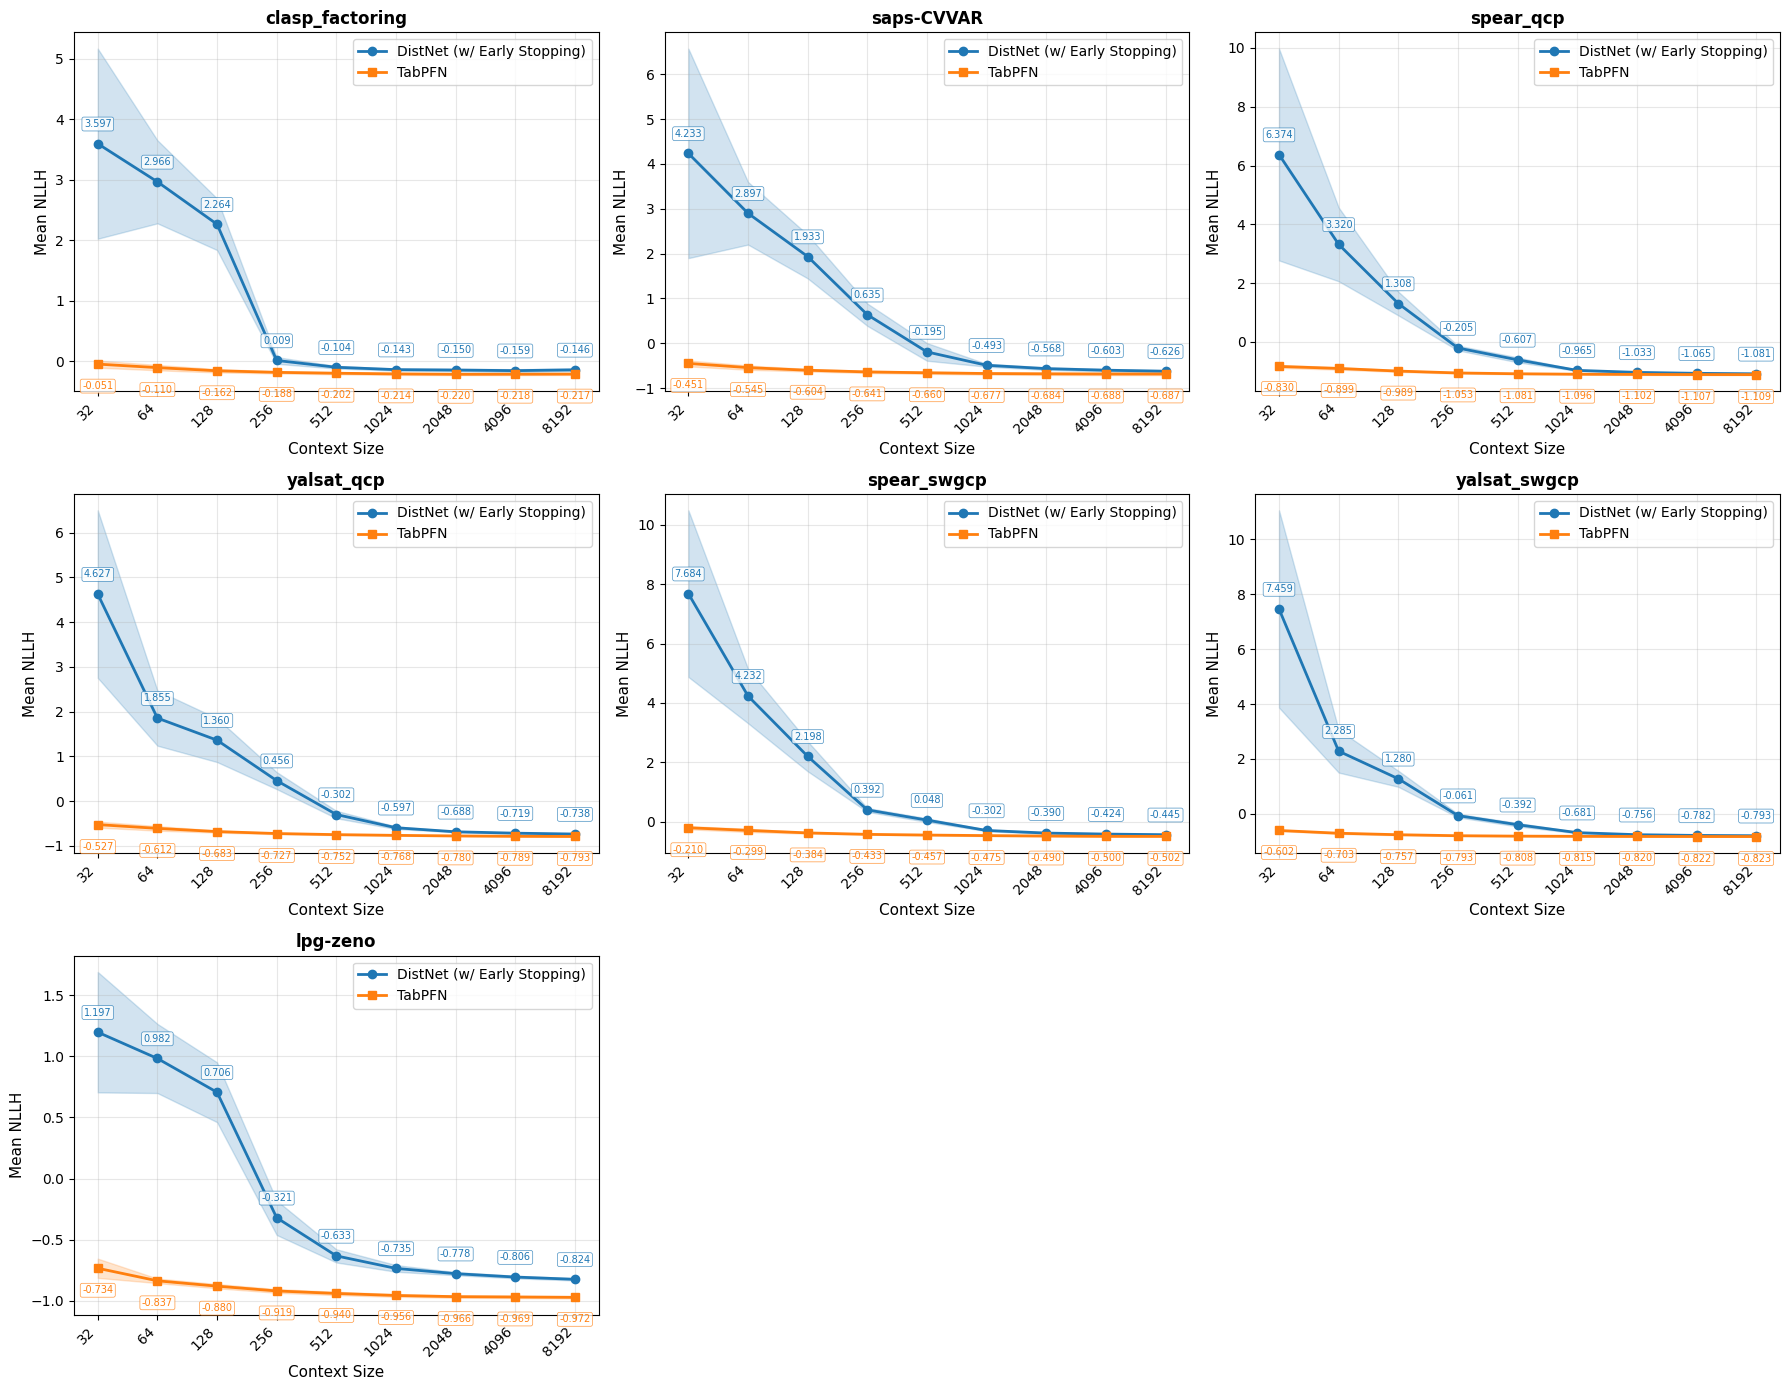


=== Plot generated successfully! ===
Saved as: phase1_context_size_analysis_from_32.png
Context sizes plotted: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict
import pickle

# Define paths
base_path = Path('C:/Users/ihagv/Desktop/masters_project/project_code/cluster/phase_1_2_data/phase1')
distnet_metadata_path = base_path / 'distnet' / 'metadata'
tabpfn_metadata_path = base_path / 'tabpfn' / 'metadata'

def nested_dict():
    """Helper function to create nested defaultdicts"""
    return defaultdict(nested_dict)

# Initialize dictionaries
distnet_phase1_dict = nested_dict()
tabpfn_phase1_dict = nested_dict()

# Process distnet files
print("Processing distnet phase1 metadata files...")
distnet_count = 0
for pkl_file in distnet_metadata_path.glob('*.pkl'):
    parts = pkl_file.stem.split('_')
    
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):  # Skip 'distnet'
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    context_size = parts[fold_idx + 4]
    
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    nllh = data['metrics']['nllh']
    distnet_phase1_dict[scenario][fold][context_size][seed_context] = nllh
    distnet_count += 1
    
print(f"Loaded {distnet_count} distnet phase1 files")

# Process tabpfn files
print("Processing tabpfn phase1 metadata files...")
tabpfn_count = 0
for pkl_file in tabpfn_metadata_path.glob('*.pkl'):
    parts = pkl_file.stem.split('_')
    
    scenario_parts = []
    fold_idx = None
    for i, part in enumerate(parts[1:], start=1):  # Skip 'tabpfn'
        if part.isdigit():
            fold_idx = i
            break
        scenario_parts.append(part)
    
    scenario = '_'.join(scenario_parts)
    fold = parts[fold_idx]
    seed_context = parts[fold_idx + 1]
    context_size = parts[fold_idx + 4]
    
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    
    nllh = data['metrics']['nllh']
    tabpfn_phase1_dict[scenario][fold][context_size][seed_context] = nllh
    tabpfn_count += 1

print(f"Loaded {tabpfn_count} tabpfn phase1 files")

# Convert defaultdicts to regular dicts
def convert_to_dict(d):
    if isinstance(d, defaultdict):
        d = {k: convert_to_dict(v) for k, v in d.items()}
    return d

distnet_phase1_dict = convert_to_dict(distnet_phase1_dict)
tabpfn_phase1_dict = convert_to_dict(tabpfn_phase1_dict)

print("\n=== Dictionaries created successfully! ===")

# Define configurations
SCENARIOS = [
    "clasp_factoring",
    "saps-CVVAR",
    "spear_qcp",
    "yalsat_qcp",
    "spear_swgcp",
    "yalsat_swgcp",
    "lpg-zeno",
]

ALL_CONTEXT_SIZES = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
CONTEXT_SEEDS = [100, 200, 300]
FOLDS = range(10)

# Convert to strings
CONTEXT_SEEDS_STR = [str(cs) for cs in CONTEXT_SEEDS]
FOLDS_STR = [str(f) for f in FOLDS]

def compute_mean_std_for_context_size(data_dict, scenario, context_size):
    """
    Compute mean and std NLLH for a given scenario and context_size
    Aggregation: for each fold, average context_seeds -> compute mean and std over folds
    """
    fold_means = []
    
    for fold in FOLDS_STR:
        context_seed_values = []
        
        for context_seed in CONTEXT_SEEDS_STR:
            try:
                nllh = data_dict[scenario][fold][context_size][context_seed]
                context_seed_values.append(nllh)
            except (KeyError, TypeError):
                pass
        
        # Average over context seeds for this fold
        if context_seed_values:
            fold_means.append(np.mean(context_seed_values))
    
    # Compute mean and std over folds
    if fold_means:
        return np.mean(fold_means), np.std(fold_means)
    else:
        return None, None

def plot_phase1_context_size_analysis(x_start=2):
    """
    Plot NLLH vs Context Size for each scenario
    
    Parameters:
    -----------
    x_start : int
        Lower boundary of context size for plotting (default: 2)
    """
    # Filter context sizes based on x_start
    context_sizes = [cs for cs in ALL_CONTEXT_SIZES if cs >= x_start]
    context_sizes_str = [str(cs) for cs in context_sizes]
    
    # Create plots
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    axes = axes.flatten()
    
    for idx, scenario in enumerate(SCENARIOS):
        ax = axes[idx]
        
        # Compute mean and std NLLH for each context size
        distnet_means = []
        distnet_stds = []
        tabpfn_means = []
        tabpfn_stds = []
        
        for context_size in context_sizes_str:
            distnet_mean, distnet_std = compute_mean_std_for_context_size(distnet_phase1_dict, scenario, context_size)
            tabpfn_mean, tabpfn_std = compute_mean_std_for_context_size(tabpfn_phase1_dict, scenario, context_size)
            
            distnet_means.append(distnet_mean)
            distnet_stds.append(distnet_std if distnet_std is not None else 0)
            tabpfn_means.append(tabpfn_mean)
            tabpfn_stds.append(tabpfn_std if tabpfn_std is not None else 0)
        
        # Convert to numpy arrays
        distnet_means = np.array(distnet_means)
        distnet_stds = np.array(distnet_stds)
        tabpfn_means = np.array(tabpfn_means)
        tabpfn_stds = np.array(tabpfn_stds)
        
        # Plot the lines with shaded std regions (using log scale for x-axis)
        ax.plot(context_sizes, distnet_means, marker='o', linewidth=2, markersize=6, label='DistNet (w/ Early Stopping)', color='#1f77b4')
        ax.fill_between(context_sizes, distnet_means - distnet_stds, distnet_means + distnet_stds, 
                         color='#1f77b4', alpha=0.2)
        
        ax.plot(context_sizes, tabpfn_means, marker='s', linewidth=2, markersize=6, label='TabPFN', color='#ff7f0e')
        ax.fill_between(context_sizes, tabpfn_means - tabpfn_stds, tabpfn_means + tabpfn_stds, 
                         color='#ff7f0e', alpha=0.2)
        
        # Annotate points with smart positioning to avoid overlaps
        for i, (x, y_dist, y_tab) in enumerate(zip(context_sizes, distnet_means, tabpfn_means)):
            if y_dist is not None and not np.isnan(y_dist):
                # Calculate vertical distance between the two lines at this x
                if y_tab is not None and not np.isnan(y_tab):
                    diff = abs(y_dist - y_tab)
                    # If lines are close, alternate positions
                    if diff < 0.05:  # Threshold for "close"
                        # Place DistNet above and TabPFN below
                        distnet_offset = 12
                        tabpfn_offset = -18
                    else:
                        # Place based on which line is higher
                        if y_dist > y_tab:
                            distnet_offset = 12
                            tabpfn_offset = -18
                        else:
                            distnet_offset = -18
                            tabpfn_offset = 12
                else:
                    distnet_offset = 12
                    tabpfn_offset = -18
                
                # Annotate DistNet
                ax.annotate(f'{y_dist:.3f}', 
                           xy=(x, y_dist), 
                           xytext=(0, distnet_offset),
                           textcoords='offset points',
                           ha='center',
                           fontsize=7,
                           color='#1f77b4',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#1f77b4', alpha=0.8, linewidth=0.5))
                
                # Annotate TabPFN
                if y_tab is not None and not np.isnan(y_tab):
                    ax.annotate(f'{y_tab:.3f}', 
                               xy=(x, y_tab), 
                               xytext=(0, tabpfn_offset),
                               textcoords='offset points',
                               ha='center',
                               fontsize=7,
                               color='#ff7f0e',
                               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#ff7f0e', alpha=0.8, linewidth=0.5))
        
        # Set log scale for x-axis
        ax.set_xscale('log', base=2)
        ax.set_xlabel('Context Size', fontsize=11)
        ax.set_ylabel('Mean NLLH', fontsize=11)
        ax.set_title(f'{scenario}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xticks(context_sizes)
        ax.set_xticklabels(context_sizes, rotation=45, ha='right')
    
    # Hide extra subplots (we have 7 scenarios but 9 subplot positions)
    for idx in range(len(SCENARIOS), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    filename = f'phase1_context_size_analysis_from_{x_start}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n=== Plot generated successfully! ===")
    print(f"Saved as: {filename}")
    print(f"Context sizes plotted: {context_sizes}")

# Example usage: plot with default x_start=2 (all context sizes)
plot_phase1_context_size_analysis(x_start=32)